# 01 - Indexing Basics: From Raw Documents to a Searchable Vector Store

**Phase 1** of the RAG exploration project. This notebook covers:

1. **Loading** the scraped LangChain documentation from JSON
2. **Exploring** the corpus (sections, sizes, content types)
3. **Cleaning** the raw MDX (strip base64 blobs, JSX tags, frontmatter)
4. **Chunking** with a naive `RecursiveCharacterTextSplitter`
5. **Embedding** with `nomic-embed-text` via Ollama
6. **Storing** in ChromaDB
7. **Validating** with sanity-check queries
8. **Recording** baseline metrics

---

## 0. Setup

In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

# Ensure the project root is on sys.path so we can import src/ and notebooks/utils/
PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ingestion.loaders import load_scraped_documents
from src.ingestion.cleaners import clean_corpus
from notebooks.utils.display import (
    corpus_summary_table,
    chunk_stats_table,
    display_doc_preview,
    display_retrieval_results,
    section_breakdown,
)
from notebooks.utils.metrics import IndexingMetrics, benchmark_queries, timed_retrieval

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

print(f"Project root: {PROJECT_ROOT}")

Project root: D:\Astyan\rag-exploration


## 1. Load the Corpus

We load documents from the JSON files produced by the scraper (`scripts/scrape_docs.py`).
Each document has `page_content` (raw MDX text) and `metadata` (source URL, title, section, content type).

In [2]:
# Load the full corpus
docs = load_scraped_documents(str(PROJECT_ROOT / "data" / "raw" / "langchain_docs.json"))
print(f"Total documents loaded: {len(docs)}")

Loaded 1463 documents from D:\Astyan\rag-exploration\data\raw\langchain_docs.json
Total documents loaded: 1463


In [3]:
# Preview the first document
display_doc_preview(docs[0])

## 2. Corpus Exploration

Before indexing, let's understand what we're working with.

In [4]:
# Per-section breakdown
breakdown = section_breakdown(docs)
display(breakdown)

,count,total_chars,avg_chars,min_chars,max_chars
section,,,,,
integrations,1322,25347936,19173.930408,24,6685750
langchain,56,1194619,21332.482143,0,84280
langgraph,37,869972,23512.756757,0,109934
deepagents,17,283453,16673.705882,3639,31123
other,10,88428,8842.800000,1648,32489
contributing,10,83523,8352.300000,19,34158
reference,8,2285,285.625000,0,2285
concepts,3,41554,13851.333333,7312,22422


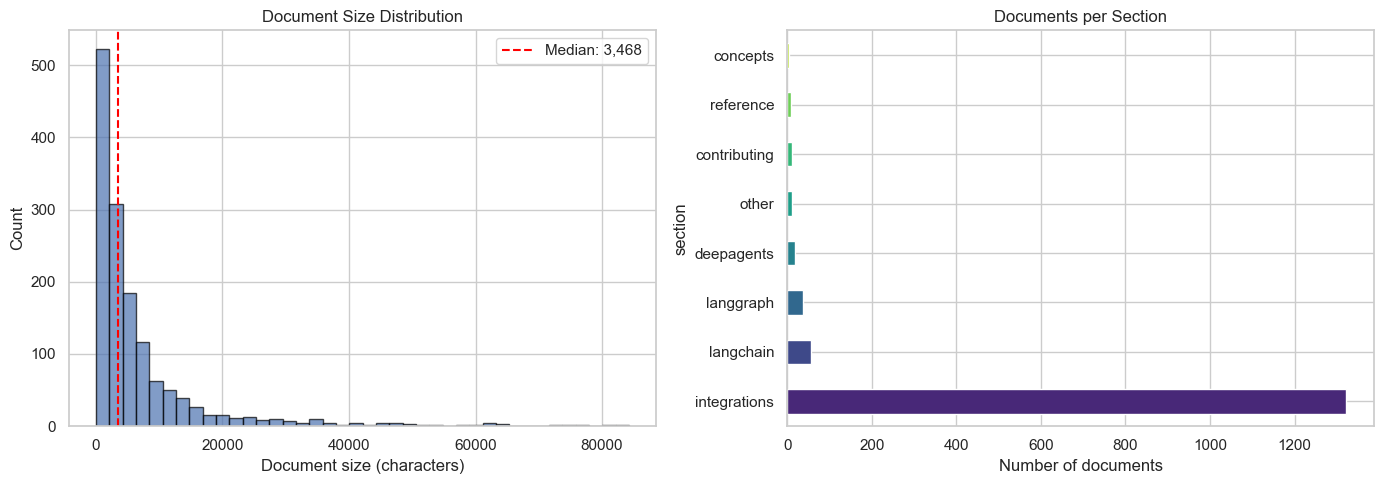

In [5]:
# Distribution of document sizes
df = corpus_summary_table(docs)

data = df["chars"]
data = data[data < data.quantile(0.99)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of document sizes
axes[0].hist(data, bins=40, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Document size (characters)")
axes[0].set_ylabel("Count")
axes[0].set_title("Document Size Distribution")
axes[0].axvline(data.median(), color="red", linestyle="--", label=f"Median: {data.median():,.0f}")
axes[0].legend()

# Documents per section
section_counts = df["section"].value_counts()
section_counts.plot.barh(ax=axes[1], color=sns.color_palette("viridis", len(section_counts)))
axes[1].set_xlabel("Number of documents")
axes[1].set_title("Documents per Section")

plt.tight_layout()
plt.show()

In [6]:
# Content type distribution
ct_counts = df["content_type"].value_counts()
print(ct_counts.to_string())

content_type
code-heavy    1023
narrative      237
reference      135
procedural      68


---
## 3. Cleaning the Corpus

The raw MDX files contain a lot of noise that will pollute the vector store:
- **Base64 blobs**: Encoded images/fonts in integration pages (the biggest problem)
- **JSX/MDX tags**: `<Tip>`, `<CodeGroup>`, `<Card>`, etc.
- **YAML frontmatter**: Metadata headers not useful for retrieval
- **Template variables**: `${variable}` placeholders

We apply `clean_corpus()` from `src/ingestion/cleaners.py` to strip all of this before chunking.

In [7]:
cleaned_docs, clean_stats = clean_corpus(docs, min_content_length=50)

print("Cleaning results:")
print(f"  Before: {clean_stats['original_count']} docs, {clean_stats['original_total_chars']:,} chars")
print(f"  After:  {clean_stats['cleaned_count']} docs, {clean_stats['cleaned_total_chars']:,} chars")
print(f"  Dropped: {clean_stats['dropped_count']} docs (too short after cleaning)")
reduction = 1 - clean_stats['cleaned_total_chars'] / clean_stats['original_total_chars']
print(f"  Size reduction: {reduction:.1%}")

Cleaning results:
  Before: 1463 docs, 27,911,770 chars
  After:  1445 docs, 11,065,586 chars
  Dropped: 18 docs (too short after cleaning)
  Size reduction: 60.4%


In [8]:
# Compare before/after for a sample document
import random
random.seed(42)
sample_idx = random.choice([i for i, d in enumerate(docs) if "integration" in d.metadata.get("section", "")])
print(f"Sample document: {docs[sample_idx].metadata.get('title', '?')} [{docs[sample_idx].metadata.get('section', '?')}]")
print(f"  Before cleaning: {len(docs[sample_idx].page_content):,} chars")

from src.ingestion.cleaners import clean_document
cleaned_sample = clean_document(docs[sample_idx])
print(f"  After cleaning:  {len(cleaned_sample.page_content):,} chars")
print(f"\nFirst 500 chars after cleaning:")
print(cleaned_sample.page_content[:500])

Sample document: Vespa integration [integrations]
  Before cleaning: 14,934 chars
  After cleaning:  14,891 chars

First 500 chars after cleaning:
>[Vespa](https://vespa.ai/) is a fully featured search engine and vector database. It supports vector search (ANN), lexical search, and search in structured data, all in the same query.

This notebook shows how to use `Vespa.ai` as a LangChain vector store.

You'll need to install `langchain-community` with `pip install -qU langchain-community` to use this integration

In order to create the vector store, we use
[pyvespa](https://pyvespa.readthedocs.io/en/latest/index.html) to create a
connectio


In [9]:
# Corpus stats after cleaning
print("Cleaned corpus breakdown:")
cleaned_breakdown = section_breakdown(cleaned_docs)
display(cleaned_breakdown)

Cleaned corpus breakdown:


,count,total_chars,avg_chars,min_chars,max_chars
section,,,,,
integrations,1320,8628580,6536.803030,150,301861
langchain,51,1123660,22032.549020,218,73277
langgraph,35,850312,24294.628571,742,107520
deepagents,17,269949,15879.352941,3424,30510
other,10,82214,8221.400000,1647,31943
contributing,8,69405,8675.625000,1788,31095
concepts,3,40417,13472.333333,6542,22404
reference,1,1049,1049.000000,1049,1049


---
## 4. Chunking - Naive Baseline

We use `RecursiveCharacterTextSplitter` with the default config:
- `chunk_size=1000`
- `chunk_overlap=200`
- Separators: `["\n\n", "\n", " ", ""]`

This is a deliberate baseline - Phase 2 will compare multiple strategies.

In [10]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

CHUNK_SIZE = 1000
CHUNK_OVERLAP = 200

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", " ", ""],
    length_function=len,
)

chunks = splitter.split_documents(cleaned_docs)
print(f"Documents: {len(cleaned_docs)} -> Chunks: {len(chunks)}")
print(f"Average expansion ratio: {len(chunks)/len(cleaned_docs):.1f}x")

d:\Astyan\rag-exploration\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Documents: 1445 -> Chunks: 15419
Average expansion ratio: 10.7x


In [11]:
# Chunk size statistics
stats = chunk_stats_table(chunks)
display(stats)

,chars
metric,
count,15419
mean,807
std,243
min,3
25%,736
50%,909
75%,977
max,1000


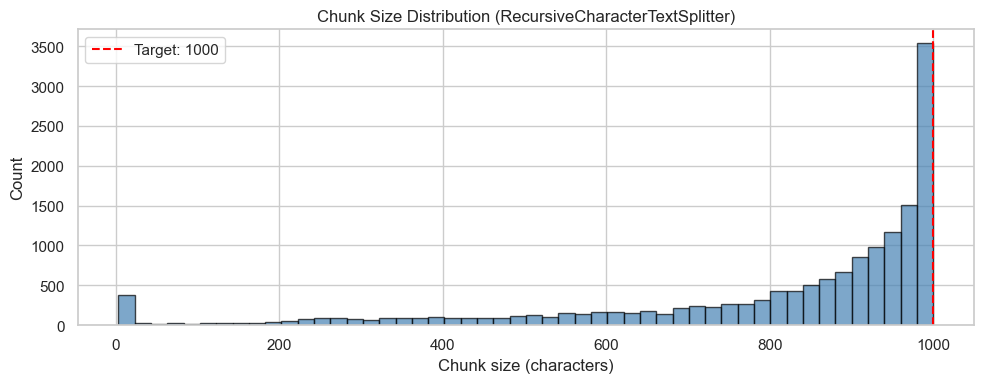

In [12]:
# Chunk size distribution
chunk_sizes = [len(c.page_content) for c in chunks]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(chunk_sizes, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(CHUNK_SIZE, color="red", linestyle="--", label=f"Target: {CHUNK_SIZE}")
ax.set_xlabel("Chunk size (characters)")
ax.set_ylabel("Count")
ax.set_title("Chunk Size Distribution (RecursiveCharacterTextSplitter)")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Preview a few chunks to sanity-check quality
print("=" * 60)
for i in [0, len(chunks)//2, len(chunks)-1]:
    print(f"\n--- Chunk {i} (from: {chunks[i].metadata.get('title', '?')}) ---")
    print(chunks[i].page_content[:400])
    print(f"... [{len(chunks[i].page_content)} chars]")
    print()


--- Chunk 0 (from: Errors) ---
This page contains guides around resolving common errors you may find while building with LangChain and LangGraph.

Errors referenced below will have an `lc_error_code` property corresponding to one of the below codes when they are thrown in code.
... [247 chars]


--- Chunk 7709 (from: Friendli integration) ---
```text
... [7 chars]


--- Chunk 15418 (from: Versioning) ---
# Upgrade to a specific version
pip install langgraph==1.0.0
```

```bash Deep Agents
# Upgrade to the latest version
pip install -U deepagents

# Upgrade to a specific version
pip install deepagents==0.1.0
```

:::

:::js

```bash LangChain
# Upgrade to the latest version
npm update langchain @langchain/core

# Install a specific version
npm install langchain@1.0.0 @langchain/core@1.0.0
```

```b
... [973 chars]



---
## 5. Embedding & Indexing in ChromaDB

We embed all chunks with `nomic-embed-text` via Ollama and store them in a persistent ChromaDB collection.

> **Prerequisite:** Ollama must be running with the model pulled:
> ```bash
> ollama pull nomic-embed-text
> ```

In [14]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="nomic-embed-text")

# Quick sanity check - embed a single sentence
test_vec = embeddings.embed_query("Hello world")
print(f"Embedding dimension: {len(test_vec)}")
print(f"First 5 values: {test_vec[:5]}")

Embedding dimension: 768
First 5 values: [-0.006795166, 0.031060228, -0.15566307, 0.036690544, 0.022703571]


In [15]:
from langchain_chroma import Chroma

PERSIST_DIR = str(PROJECT_ROOT / "vectorstore" / "chroma_db")
COLLECTION_NAME = "langchain_docs_naive"

print(f"Indexing {len(chunks)} chunks into ChromaDB...")
print(f"Persist directory: {PERSIST_DIR}")
print(f"Collection: {COLLECTION_NAME}")
print("This may take several minutes depending on your hardware.")
print()

start_time = time.perf_counter()

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory=PERSIST_DIR,
    collection_name=COLLECTION_NAME,
)

indexing_time = time.perf_counter() - start_time

print(f"Indexing completed in {indexing_time:.1f}s")
print(f"Collection size: {vectorstore._collection.count()} vectors")

Indexing 15419 chunks into ChromaDB...
Persist directory: D:\Astyan\rag-exploration\vectorstore\chroma_db
Collection: langchain_docs_naive
This may take several minutes depending on your hardware.

Indexing completed in 86.4s
Collection size: 15419 vectors


---
## 6. Validation - Sanity-Check Queries

We test the index with 5 questions to qualitatively verify that retrieval works.
For each query we check:
- Are the retrieved documents relevant?
- Do the source URLs make sense?
- Are the similarity scores reasonable?

In [16]:
VALIDATION_QUERIES = [
    "How do I create a basic RAG chain in LangChain?",
    "What is an Embedding model?",
    "How does RecursiveCharacterTextSplitter work?",
    "What are the different types of memory in LangChain?",
    "How do I use Ollama with LangChain?",
]

In [17]:
# Run each query and display results
for query in VALIDATION_QUERIES:
    result = timed_retrieval(vectorstore, query, k=5)
    display_retrieval_results(
        query,
        list(zip(result.docs, result.scores)),
        max_content_chars=250,
    )
    print(f"  ⏱ Latency: {result.latency_ms:.1f} ms")
    print()

  ⏱ Latency: 33.3 ms



  ⏱ Latency: 16.9 ms



  ⏱ Latency: 16.8 ms



  ⏱ Latency: 18.3 ms



  ⏱ Latency: 17.6 ms



In [18]:
# Summary table of all queries
benchmark_df = benchmark_queries(vectorstore, VALIDATION_QUERIES, k=5)
display(benchmark_df)

,query,num_results,top_score,avg_score,latency_ms,top_source
0,How do I create a basic RAG chain in LangChain?,5,0.495646,0.508505,17.8,Clearml integrations
1,What is an Embedding model?,5,0.513252,0.533152,16.2,Chat model integrations
2,How does RecursiveCharacterTextSplitter work?,5,0.481138,0.584955,16.3,Rememberizer integration
3,What are the different types of memory in LangChain?,5,0.470124,0.502957,16.7,Memory overview
4,How do I use Ollama with LangChain?,5,0.468174,0.615178,17.2,Google jobs integration


---
## 7. Baseline Metrics Summary

Let's record all the key metrics from this Phase 1 baseline.

In [19]:
metrics = IndexingMetrics(
    num_raw_docs=len(docs),
    num_chunks=len(chunks),
    chunk_sizes=[len(c.page_content) for c in chunks],
    indexing_time_s=indexing_time,
)

summary = metrics.summary()
summary["cleaned_docs"] = len(cleaned_docs)
summary["dropped_docs"] = clean_stats["dropped_count"]
summary["embedding_model"] = "nomic-embed-text"
summary["embedding_dim"] = len(test_vec)
summary["chunk_strategy"] = "RecursiveCharacterTextSplitter"
summary["chunk_size"] = CHUNK_SIZE
summary["chunk_overlap"] = CHUNK_OVERLAP
summary["avg_retrieval_latency_ms"] = round(benchmark_df["latency_ms"].mean(), 1)

print("Phase 1 - Baseline Metrics")
print("=" * 40)
for k, v in summary.items():
    print(f"  {k:30s}: {v}")

Phase 1 - Baseline Metrics
  raw_documents                 : 1463
  chunks                        : 15419
  avg_chunk_chars               : 807
  min_chunk_chars               : 3
  max_chunk_chars               : 1000
  indexing_time_s               : 86.44
  cleaned_docs                  : 1445
  dropped_docs                  : 18
  embedding_model               : nomic-embed-text
  embedding_dim                 : 768
  chunk_strategy                : RecursiveCharacterTextSplitter
  chunk_size                    : 1000
  chunk_overlap                 : 200
  avg_retrieval_latency_ms      : 16.8


In [20]:
# Save metrics to results/
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)

metrics_path = results_dir / "phase1_indexing_baseline.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"Metrics saved to {metrics_path}")

Metrics saved to D:\Astyan\rag-exploration\results\phase1_indexing_baseline.json


---
## 8. Reloading the Vector Store

Since ChromaDB is persisted to disk, we can reload it in future notebooks without re-indexing.

In [21]:
# Example: reloading the existing vector store
vectorstore_reloaded = Chroma(
    persist_directory=PERSIST_DIR,
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
)

print(f"Reloaded collection: {vectorstore_reloaded._collection.count()} vectors")

# Verify it works
test_results = vectorstore_reloaded.similarity_search("What is LangChain?", k=3)
print(f"Test query returned {len(test_results)} results")
for i, doc in enumerate(test_results, 1):
    print(f"  {i}. {doc.metadata.get('title', '?')} ({len(doc.page_content)} chars)")

Reloaded collection: 15419 vectors
Test query returned 3 results
  1. Google jobs integration (11 chars)
  2. Langfuse integrations (942 chars)
  3. Needle integration (58 chars)


## Observations & Next Steps

### What we built
- A naive but functional RAG index using `RecursiveCharacterTextSplitter` + `nomic-embed-text` + ChromaDB
- Baseline metrics for comparison in later phases

### What to observe
- Are chunk sizes well-distributed around the target (1000 chars)?
- Do the validation queries return relevant documents?
- Are there any sections of the corpus that seem problematic?

### Next: Phase 2 - Chunking Strategies (`02_chunking_strategies.ipynb`)
We will compare 5 different chunking approaches:
1. Fixed-size character splitting
2. Recursive character splitting (current baseline)
3. Token-based splitting
4. Markdown-aware splitting
5. Semantic splitting

Each will be evaluated on the same retrieval benchmark to identify the best strategy.